# FICTURE F1 metric

Agreement between **FICTURE factor identity** and a segmentation's **cell types**.
For every transcript we assign two canonical (parent-type) labels and score them as a
hard-label classification:

- **pred** = cell type of the nearest FICTURE pixel's top factor `K1` (within 5 um)
- **true** = cell type of the segmentation cell whose polygon the transcript lies in

`compute_ficture_f1` writes `metrics/<cohort>/ficture/ficture_f1.csv` with columns
`method, sample, cell_type, tp, fp, fn, precision, recall, f1`. Each sample block has
one row per cell type plus four summary rows (`f1_{micro,macro}_{all,vascular}`);
`sample == "all_samples"` holds the counts pooled across samples.

**How to plot this.** The prediction is a hard argmax factor label with no retained
confidence, so there is no score to threshold: **a precision-recall *curve* does not
apply** (it would collapse to one point per class). The right views are therefore the
single operating point per method/class plus per-type resolution:
1. macro & micro F1 per method (headline ranking),
2. per-cell-type F1 heatmap (where methods differ),
3. precision-vs-recall scatter of each method's operating point against F1 iso-contours
   (the correct substitute for a PR curve),
4. per-sample spread of macro F1 (stability).

## Compute FICTURE F1

In [ ]:
from cellseg_benchmark.metrics import (
    compute_ficture_f1,
    compute_metric_for_all_methods,
)

compute_metric_for_all_methods(
    compute_ficture_f1,
    results_name="ficture/ficture_f1.csv",
    cohort="aging",
    celltype_col="cell_type_revised",
    overwrite=False,
)

## Load results

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from cellseg_benchmark import BASE_PATH
from cellseg_benchmark._constants import method_colors

cohort = "aging"
results_file = Path(BASE_PATH) / "metrics" / cohort / "ficture" / "ficture_f1.csv"
plot_path = results_file.parent / "plots"
plot_path.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(results_file, index_col=0)

summary_rows = ["f1_micro_all", "f1_macro_all", "f1_micro_vascular", "f1_macro_vascular"]
pooled = df[df["sample"] == "all_samples"]                      # pooled over samples
per_type = pooled[~pooled["cell_type"].isin(summary_rows)]      # one row per cell type
summ = pooled[pooled["cell_type"].isin(summary_rows)]           # the four F1 summaries

# rank methods by pooled macro F1 (best first); reuse as consistent order everywhere
order = (
    summ[summ["cell_type"] == "f1_macro_all"]
    .set_index("method")["f1"].sort_values(ascending=False).index.tolist()
)
pal = {m: method_colors.get(m, "0.6") for m in order}
df.head()

,method,sample,cell_type,tp,fp,fn,precision,recall,f1
323,Baysor_2D_Cellpose_2_DAPI_Transcripts_0.8,aging_s1_r1,Astrocytes,3657093.0,451915.0,4405623.0,0.890018,0.453581,0.600916
324,Baysor_2D_Cellpose_2_DAPI_Transcripts_0.8,aging_s1_r1,BAMs,3359.0,135404.0,46284.0,0.024207,0.067663,0.035657
325,Baysor_2D_Cellpose_2_DAPI_Transcripts_0.8,aging_s1_r1,ECs,1489740.0,1151844.0,664771.0,0.563957,0.691452,0.621230
326,Baysor_2D_Cellpose_2_DAPI_Transcripts_0.8,aging_s1_r1,Ependymal,174229.0,80751.0,37749.0,0.683305,0.821920,0.746230
327,Baysor_2D_Cellpose_2_DAPI_Transcripts_0.8,aging_s1_r1,Microglia,630962.0,1006610.0,391115.0,0.385303,0.617333,0.474470


## 1. Method ranking: macro & micro F1

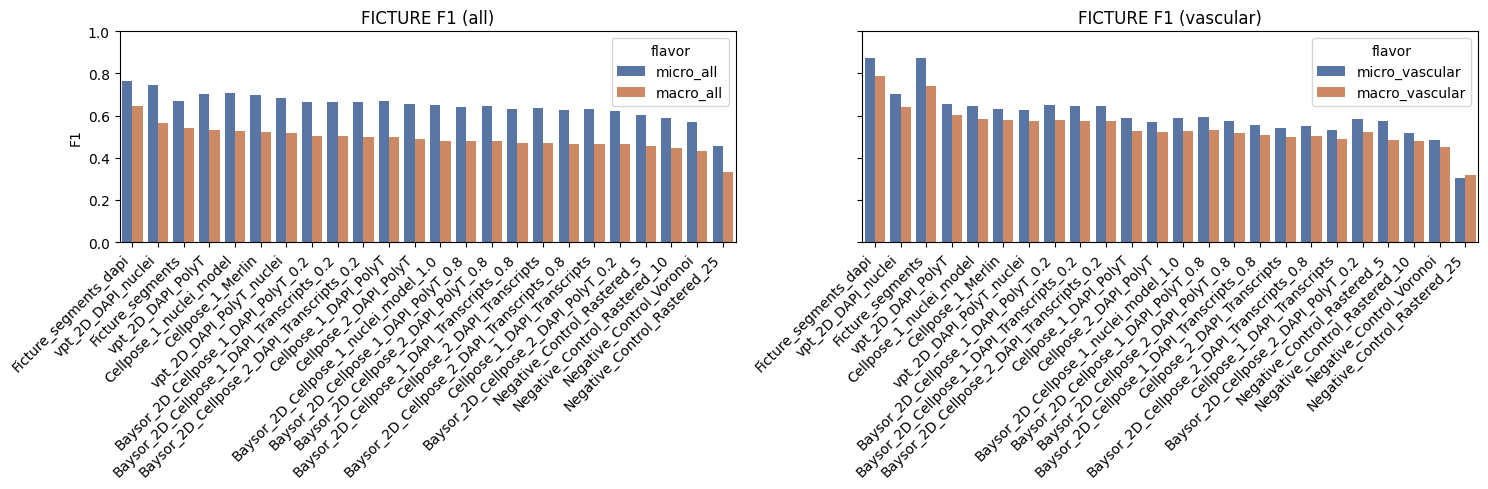

In [2]:
# macro = unweighted mean over cell types; micro = abundance-weighted (pooled counts).
# shown for all cell types and for the vascular subset (ECs/Pericytes/SMCs/VLMCs).
plot_df = summ.copy()
plot_df["flavor"] = plot_df["cell_type"].str.replace("f1_", "", regex=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, scope in zip(axes, ["all", "vascular"]):
    sub = plot_df[plot_df["flavor"].str.endswith(scope)]
    sns.barplot(
        data=sub, x="method", y="f1",
        hue="flavor", order=order, ax=ax,
        palette={f"micro_{scope}": "#4C72B0", f"macro_{scope}": "#DD8452"},
    )
    ax.set_title(f"FICTURE F1 ({scope})")
    ax.set_ylim(0, 1)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
    for lbl in ax.get_xticklabels():
        lbl.set_ha("right")
axes[0].set_ylabel("F1")
plt.tight_layout()
plt.savefig(plot_path / "ficture_f1_method_ranking.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Per-cell-type F1 (methods x cell types)

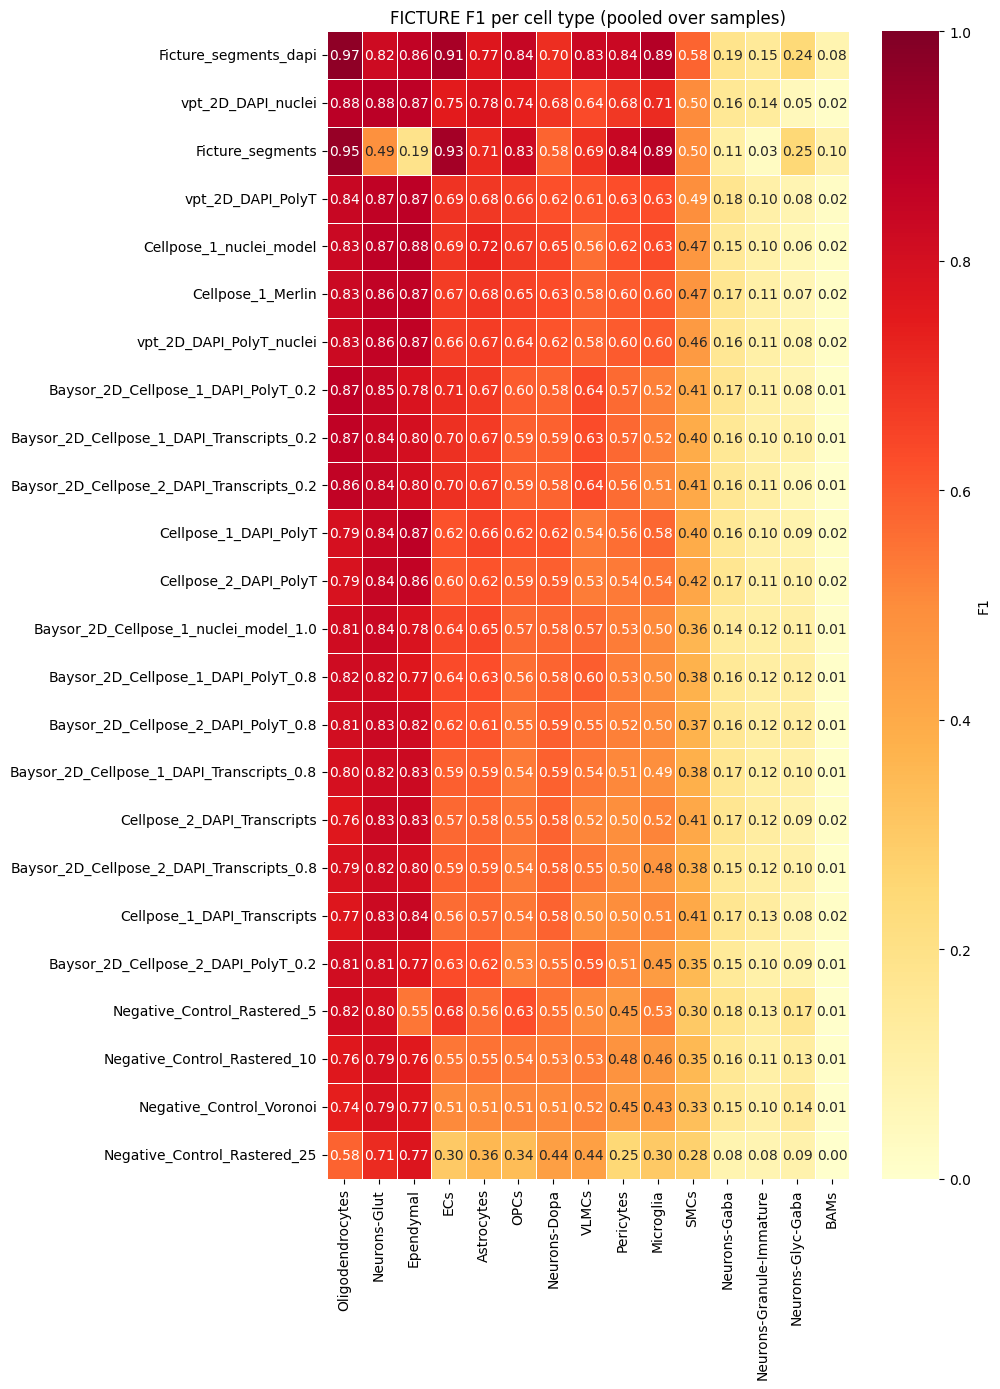

In [3]:
mat = per_type.pivot(index="method", columns="cell_type", values="f1").loc[order]
mat = mat.reindex(columns=mat.mean().sort_values(ascending=False).index)  # easy types left

fig, ax = plt.subplots(figsize=(max(10, 0.6 * mat.shape[1]), 0.5 * mat.shape[0] + 2))
sns.heatmap(mat, annot=True, fmt=".2f", cmap="YlOrRd", vmin=0, vmax=1,
            linewidths=0.5, cbar_kws={"label": "F1"}, ax=ax)
ax.set_title("FICTURE F1 per cell type (pooled over samples)")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(plot_path / "ficture_f1_celltype_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Precision vs recall (operating point per method)

One point per method (pooled micro counts) rather than a swept PR curve, since labels
are hard. Grey lines are F1 iso-contours: points on the same curve share an F1, so
distance from the top-right corner is a direct read of segmentation quality.

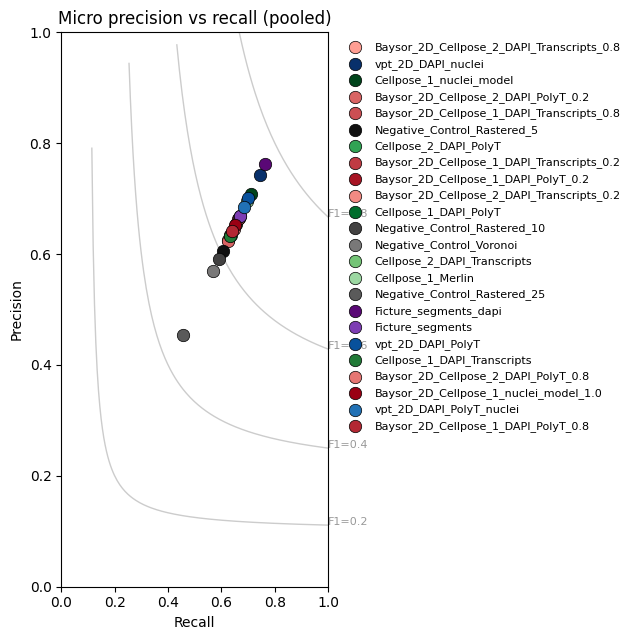

In [4]:
pr = summ[summ["cell_type"] == "f1_micro_all"]

fig, ax = plt.subplots(figsize=(6.5, 6.5))
# F1 iso-contours: precision = f*r / (2r - f)
r = np.linspace(0.01, 1, 200)
for f in [0.2, 0.4, 0.6, 0.8]:
    p = np.where(2 * r - f > 0, f * r / (2 * r - f), np.nan)
    p[(p < 0) | (p > 1)] = np.nan
    ax.plot(r, p, color="0.8", lw=1, zorder=0)
    ax.annotate(f"F1={f}", (r[~np.isnan(p)][-1], p[~np.isnan(p)][-1]),
                color="0.6", fontsize=8)

for _, row in pr.iterrows():
    ax.scatter(row["recall"], row["precision"], s=80,
               color=method_colors.get(row["method"], "0.4"),
               edgecolor="k", linewidth=0.5, label=row["method"], zorder=3)

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Micro precision vs recall (pooled)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, frameon=False)
plt.tight_layout()
plt.savefig(plot_path / "ficture_f1_precision_recall.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Per-sample spread of macro F1 (stability)

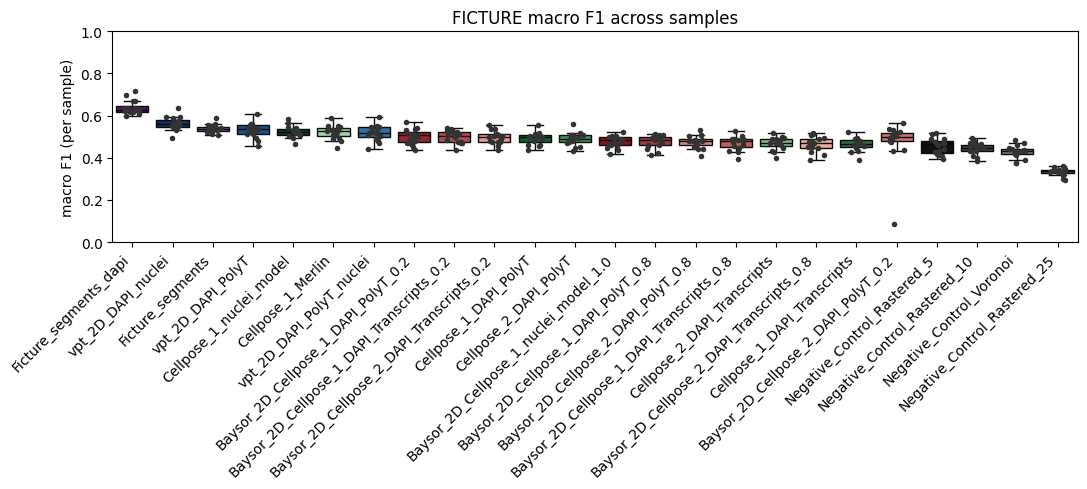

In [5]:
per_sample = df[(df["sample"] != "all_samples") & (df["cell_type"] == "f1_macro_all")]

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=per_sample, x="method", y="f1", order=order,
            hue="method", palette=pal, legend=False, fliersize=0, ax=ax)
sns.stripplot(data=per_sample, x="method", y="f1", order=order,
              color="0.2", size=4, jitter=0.2, ax=ax)
ax.set_ylim(0, 1)
ax.set_ylabel("macro F1 (per sample)")
ax.set_xlabel("")
ax.set_title("FICTURE macro F1 across samples")
ax.tick_params(axis="x", rotation=45)
for lbl in ax.get_xticklabels():
    lbl.set_ha("right")
plt.tight_layout()
plt.savefig(plot_path / "ficture_f1_per_sample.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Is FICTURE a clean reference?

FICTURE labels transcripts by factor, not by cell, so it can't be scored with cell-level metrics. Instead each transcript is scored against marker genes from the scRNA-seq reference (ABC Atlas):

- **Marker agreement:** transcripts of a cell type's positive markers should get that cell type's factor.
- **Negative markers:** a factor should contain fewer transcripts of its cell type's negative markers than expected by chance.

Factors were annotated with marker genes, so some agreement is built in. The negative-marker check is the more independent of the two.

In [6]:
import spatialdata as sd
from cellseg_benchmark._constants import ficture_factor_to_celltype, true_cluster, unreliable_celltypes
from cellseg_benchmark.metrics import get_negative_markers, get_positive_markers

n_samples = 3
samples = sorted(f.parents[2].name for f in (Path(BASE_PATH) / "samples").glob(
    f"{cohort}_*/results/Ficture/ficture_transcript_factors.parquet"))[:n_samples]
factor_type = {int(f): true_cluster[c] for f, c in ficture_factor_to_celltype.items()}

counts = []
for s in samples:
    t = pd.read_parquet(Path(BASE_PATH) / "samples" / s / "results/Ficture/ficture_transcript_factors.parquet")
    pts = sd.read_zarr(Path(BASE_PATH) / "samples" / s / "sdata_z3.zarr", selection=("points",))[f"{s}_transcripts"]
    pts = pts[["x", "gene"]].compute()
    assert len(pts) == len(t) and np.allclose(pts["x"].to_numpy(np.float32), t["x"].to_numpy())
    counts.append(pd.DataFrame({"factor": t["factor"].to_numpy(), "gene": pts["gene"].to_numpy()})
                  .groupby(["factor", "gene"], observed=True).size().unstack(fill_value=0))
    del t, pts
counts = pd.concat(counts).fillna(0).groupby(level=0).sum()
counts = counts.groupby(counts.index.map(factor_type)).sum().drop(unreliable_celltypes, errors="ignore")
print(samples, f"{int(counts.values.sum()):,} transcripts")

/home/ubuntu/miniforge3/envs/seg_postprocessing/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


['aging_s10_r0', 'aging_s10_r1', 'aging_s10_r2'] 169,510,740 transcripts


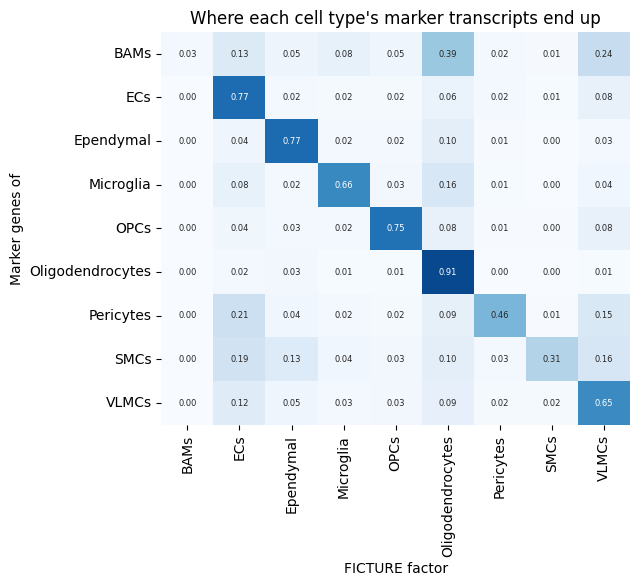

In [7]:
pos = get_positive_markers(subset_genes=set(counts.columns))
owner = pd.DataFrame([(g, true_cluster.get(c, c)) for c, genes in pos.items() for g in genes],
                     columns=["gene", "type"]).drop_duplicates()
owner = owner[~owner.gene.duplicated(keep=False) & ~owner.type.isin(unreliable_celltypes)].set_index("gene").type
types = sorted(set(owner) & set(counts.index))

conf = counts[owner.index].T.groupby(owner).sum().reindex(index=types, columns=types, fill_value=0)
mix = conf.div(conf.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(0.45 * len(types) + 2, 0.4 * len(types) + 1.5))
sns.heatmap(mix, cmap="Blues", vmin=0, vmax=1, annot=True, fmt=".2f", annot_kws={"size": 6}, cbar=False, ax=ax)
ax.set(xlabel="FICTURE factor", ylabel="Marker genes of", title="Where each cell type's marker transcripts end up");

macro marker F1: 0.56 (shuffled 0.11); negative-marker share: 0.015 (expected 0.019)


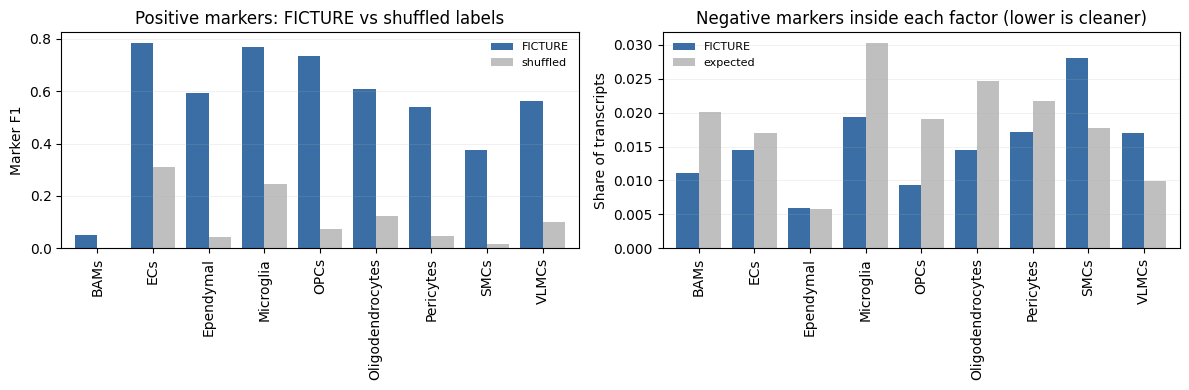

In [8]:
expected = np.outer(conf.sum(axis=1), conf.sum(axis=0)) / conf.values.sum()
f1 = pd.DataFrame({"FICTURE": 2 * np.diag(conf), "shuffled": 2 * np.diag(expected)}, index=types).div(
    conf.sum(axis=0) + conf.sum(axis=1), axis=0)

neg, _ = get_negative_markers(cohort)
neg = neg.groupby(neg.index.map(lambda c: true_cluster.get(c, c))).all()
share = counts.div(counts.sum(axis=1), axis=0)
overall = counts.sum() / counts.values.sum()
leak = pd.DataFrame({
    c: {"FICTURE": share.loc[c, g].sum(), "expected": overall[g].sum()}
    for c in types if c in neg.index
    for g in [neg.columns[neg.loc[c]].intersection(counts.columns)]
}).T

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
f1.plot.bar(ax=axs[0], color=["#3b6ea5", "0.75"], width=0.8)
axs[0].set(ylabel="Marker F1", title="Positive markers: FICTURE vs shuffled labels")
leak.plot.bar(ax=axs[1], color=["#3b6ea5", "0.75"], width=0.8)
axs[1].set(ylabel="Share of transcripts", title="Negative markers inside each factor (lower is cleaner)")
for ax in axs:
    ax.set_xlabel("")
    ax.legend(frameon=False, fontsize=8)
    ax.grid(axis="y", alpha=0.25, lw=0.5)
fig.tight_layout()
print(f"macro marker F1: {f1.FICTURE.mean():.2f} (shuffled {f1.shuffled.mean():.2f}); "
      f"negative-marker share: {leak.FICTURE.mean():.3f} (expected {leak.expected.mean():.3f})")